

  ## Setup and Model Parameters

  Import the required packages, define data paths, and set the assumptions used throughout the analysis.


In [1]:
import os
from pathlib import Path

PROJECT_DIR = Path.cwd()
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
PROCESSED_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_DIR / ".matplotlib-cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None
    plt.style.use("default")

TEMP_FILE = PROCESSED_DIR / "daily-temperature-for-depots.csv"
HUMIDITY_FILE = RAW_DIR / "mean_relative_humidity_1991-2020_0.xlsx"

WAREHOUSE_AMPLIFICATION = {
    "conservative": 2.0,
    "moderate": 3.5,
    "severe": 5.0,
}

PRODUCTIVITY_THRESHOLD_C = 27.0
PRODUCTIVITY_LOSS_PER_C = 0.04
INTERVENTIONS = {
    "Current state": 0.0,
    "Fan-assisted cooling": 7.0,
    "Enhanced ventilation": 2.0,
    "HVLS fans": 4.0,
    "Full air conditioning target": None,
}

SUMMER_MONTHS = [12, 1, 2]
NORTH_ISLAND = {
    "Auckland", "Hamilton", "Napier", "New Plymouth", "Palmerston North",
    "Tauranga", "Wellington", "Whangarei"
}

## Load and Prepare Data

Temperature data is daily by site and statistic. The depot file contains mixed date formats, so parsing is handled explicitly for `DD/MM/YYYY` and `YYYY-MM-DD` values.


In [2]:
def parse_mixed_dates(series):
    parsed = pd.to_datetime(series, format="%d/%m/%Y", errors="coerce")
    missing = parsed.isna()
    if missing.any():
        parsed.loc[missing] = pd.to_datetime(series.loc[missing], format="%Y-%m-%d", errors="coerce")
    return parsed


def clean_location(value):
    return str(value).strip()


temp_raw = pd.read_csv(TEMP_FILE)
temp_raw["date"] = parse_mixed_dates(temp_raw["date"])
temp_raw["site"] = temp_raw["site"].map(clean_location)
temp_raw["year"] = temp_raw["date"].dt.year
temp_raw["month"] = temp_raw["date"].dt.month
temp_raw["island"] = np.where(temp_raw["site"].isin(NORTH_ISLAND), "North Island", "South Island")

temp = temp_raw[temp_raw["year"].between(1960, 2022)].copy()

max_daily = temp[temp["statistic"].eq("Maximum")].copy()
min_daily = temp[temp["statistic"].eq("Minimum")].copy()

warehouse_daily = max_daily.copy()
for scenario, amplification_c in WAREHOUSE_AMPLIFICATION.items():
    warehouse_daily[f"warehouse_{scenario}_temp_c"] = warehouse_daily["temperature"] + amplification_c

print(f"Temperature rows: {len(temp):,}")
print(f"Sites: {temp['site'].nunique()}")
print(f"Date range: {temp['date'].min().date()} to {temp['date'].max().date()}")
print(sorted(temp['site'].unique()))


Temperature rows: 773,612
Sites: 12
Date range: 1960-01-01 to 2022-12-31
['Auckland', 'Blenheim', 'Christchurch', 'Dunedin', 'Hamilton', 'Napier', 'New Plymouth', 'Palmerston North', 'Queenstown', 'Tauranga', 'Wellington', 'Whangarei']


In [3]:
humidity = pd.read_excel(HUMIDITY_FILE, sheet_name="Data", skiprows=4)
humidity = humidity.rename(columns={"LOCATION": "site"})
humidity = humidity[~humidity["site"].astype(str).str.startswith("-")].copy()
humidity["site"] = humidity["site"].map(clean_location)

month_cols = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
for col in month_cols + ["YEAR"]:
    humidity[col] = pd.to_numeric(humidity[col], errors="coerce")

humidity["summer_rh"] = humidity[["DEC", "JAN", "FEB"]].mean(axis=1)
humidity_lookup = humidity.set_index("site")[["summer_rh", "YEAR"]]

site_humidity = pd.DataFrame({"site": sorted(temp["site"].unique())}).merge(
    humidity_lookup, left_on="site", right_index=True, how="left"
)

# Blenheim is not listed in the humidity workbook; use Nelson as the nearest available proxy.
if "Nelson" in humidity_lookup.index:
    nelson_rh = humidity_lookup.loc["Nelson", ["summer_rh", "YEAR"]]
    site_humidity.loc[site_humidity["site"].eq("Blenheim"), ["summer_rh", "YEAR"]] = nelson_rh.values

site_humidity


,site,summer_rh,YEAR
0,Auckland,77.833333,81.8
1,Blenheim,74.500000,80.7
2,Christchurch,75.200000,80.4
3,Dunedin,74.200000,75.4
4,Hamilton,79.866667,84.9
5,Napier,67.966667,72.7
6,New Plymouth,81.533333,83.4
7,Palmerston North,77.300000,81.3
8,Queenstown,71.433333,77.2
9,Tauranga,74.200000,78.3


## 01: How frequently do extreme heat conditions occur across warehouse locations in New Zealand?

Before estimating warehouse temperatures, we first need to understand the external climate conditions.

If New Zealand's climate is becoming warmer, warehouses may be exposed to more frequent periods of heat stress, particularly during summer months.

This section examines long-term temperature trends, the frequency of days exceeding 30°C, and regional differences in heat exposure.

### The environment is changing

**Key message:** Warehouses are operating in a progressively warmer climate than they were decades ago.


In [4]:
annual_daily_max = (
    max_daily.groupby(["site", "island", "year"], as_index=False)["temperature"]
    .mean()
    .rename(columns={"temperature": "annual_avg_daily_max_temp_c"})
)


def trend_per_decade(group):
    group = group.dropna(subset=["year", "annual_avg_daily_max_temp_c"])
    if group["year"].nunique() < 10:
        return np.nan
    slope, intercept = np.polyfit(group["year"], group["annual_avg_daily_max_temp_c"], 1)
    return slope * 10

trend_rows = []
for (site, island), group in annual_daily_max.groupby(["site", "island"]):
    trend_rows.append({
        "site": site,
        "island": island,
        "warming_trend_c_per_decade": trend_per_decade(group),
    })

trend_summary = pd.DataFrame(trend_rows).sort_values("warming_trend_c_per_decade", ascending=False)

trend_summary


,site,island,warming_trend_c_per_decade
8,Queenstown,South Island,0.327402
0,Auckland,North Island,0.247012
7,Palmerston North,North Island,0.211925
5,Napier,North Island,0.194524
4,Hamilton,North Island,0.188353
9,Tauranga,North Island,0.183484
6,New Plymouth,North Island,0.168523
1,Blenheim,South Island,0.153324
2,Christchurch,South Island,0.150411
10,Wellington,North Island,0.109299


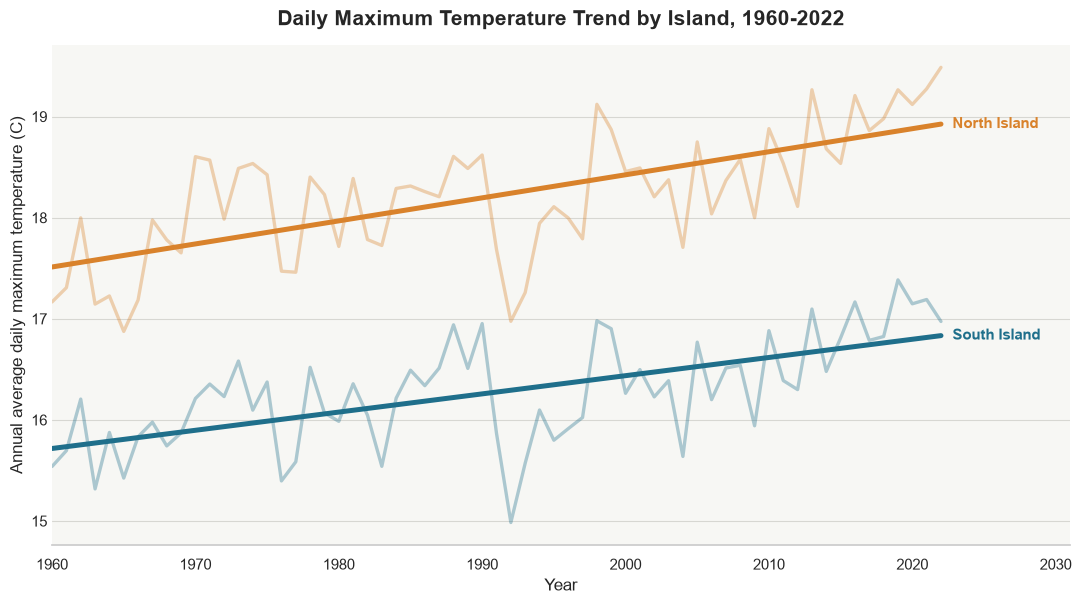

In [5]:
island_daily_max = annual_daily_max.groupby(["island", "year"], as_index=False)["annual_avg_daily_max_temp_c"].mean()

palette = {
    "North Island": "#D9822B",
    "South Island": "#1F6F8B",
}

fig, ax = plt.subplots(figsize=(11, 6.2), facecolor="white")
ax.set_facecolor("#F7F7F4")

for island in ["North Island", "South Island"]:
    group = island_daily_max[island_daily_max["island"].eq(island)].sort_values("year")
    color = palette[island]
    ax.plot(
        group["year"],
        group["annual_avg_daily_max_temp_c"],
        color=color,
        linewidth=2.4,
        alpha=0.35,
    )
    slope, intercept = np.polyfit(group["year"], group["annual_avg_daily_max_temp_c"], 1)
    ax.plot(
        group["year"],
        slope * group["year"] + intercept,
        color=color,
        linewidth=3.6,
    )
    last_year = group["year"].iloc[-1]
    last_value = slope * last_year + intercept
    ax.text(last_year + 0.8, last_value, island, color=color, va="center", fontsize=11, fontweight="bold")

ax.set_title("Daily Maximum Temperature Trend by Island, 1960-2022", fontsize=15, pad=14, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Annual average daily maximum temperature (C)")
ax.grid(axis="y", color="#D7D7D2", linewidth=0.8)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlim(island_daily_max["year"].min(), island_daily_max["year"].max() + 9)
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "01_daily_max_temperature_trend_by_island.png", dpi=200, bbox_inches="tight")
plt.show()


### Different locations have different temperatures

Depot exposure is not uniform across the country. This section compares hot-day frequency with days above 25°C by location. A hot-day is a day where maximum temperatures exceed 30°C. 

Number of days above 25 C and 30 C averaged annually from 2018-2022.


**Key message:** Heat risk is geographically uneven, so intervention priority should be based on depot-level exposure.

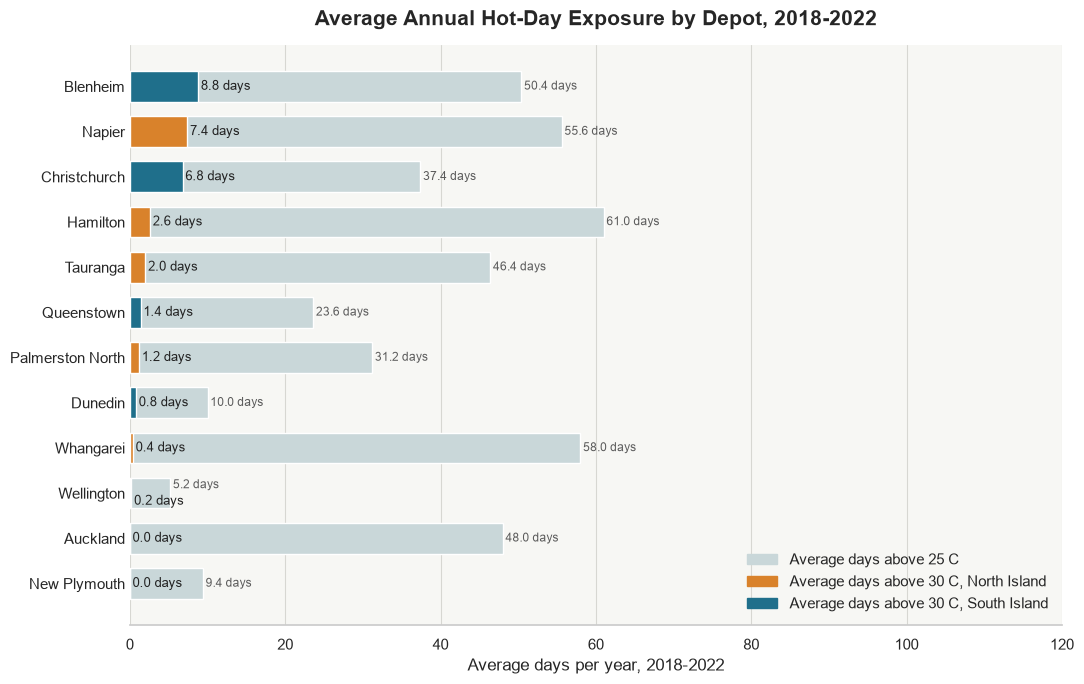

In [6]:
depot_recent_daily = max_daily[max_daily["year"].between(2018, 2022)].copy()

annual_hot_days_by_depot = (
    depot_recent_daily.groupby(["site", "island", "year"], as_index=False)
    .agg(
        hottest_day_c=("temperature", "max"),
        days_above_25c=("temperature", lambda s: s.gt(25).sum()),
        hot_days_above_30c=("temperature", lambda s: s.gt(30).sum()),
    )
)

depot_recent_summary = (
    annual_hot_days_by_depot.groupby(["site", "island"], as_index=False)
    .agg(
        hottest_day_c=("hottest_day_c", "max"),
        avg_days_above_25c=("days_above_25c", "mean"),
        avg_hot_days_above_30c=("hot_days_above_30c", "mean"),
    )
    .sort_values(["avg_hot_days_above_30c", "avg_days_above_25c", "hottest_day_c"], ascending=True)
)

palette = {
    "North Island": "#D9822B",
    "South Island": "#1F6F8B",
}
bar_colors = depot_recent_summary["island"].map(palette)
positions = np.arange(len(depot_recent_summary))

fig, ax = plt.subplots(figsize=(11, 7), facecolor="white")
ax.set_facecolor("#F7F7F4")

ax.barh(
    positions,
    depot_recent_summary["avg_days_above_25c"],
    color="#C9D7D9",
    height=0.68,
    label="Average days above 25 C",
)
ax.barh(
    positions,
    depot_recent_summary["avg_hot_days_above_30c"],
    color=bar_colors,
    height=0.68,
    label="Average days above 30 C",
)

for y, (_, row) in enumerate(depot_recent_summary.iterrows()):
    labels_are_close = (row["avg_days_above_25c"] - row["avg_hot_days_above_30c"]) < 8
    hot_label_y = y - 0.18 if labels_are_close else y
    warm_label_y = y + 0.18 if labels_are_close else y

    ax.text(
        row["avg_hot_days_above_30c"] + 0.35,
        hot_label_y,
        f"{row['avg_hot_days_above_30c']:.1f} days",
        va="center",
        fontsize=9,
        color="#222222",
        fontweight="bold" if row["avg_hot_days_above_30c"] >= 15 else "normal",
    )
    ax.text(
        max(row["avg_days_above_25c"] + 0.35, row["avg_hot_days_above_30c"] + 4),
        warm_label_y,
        f"{row['avg_days_above_25c']:.1f} days",
        va="center",
        fontsize=8.5,
        color="#5B5B5B",
    )

ax.set_yticks(positions)
ax.set_yticklabels(depot_recent_summary["site"])
ax.set_title("Average Annual Hot-Day Exposure by Depot, 2018-2022", fontsize=15, pad=14, weight="bold")
ax.set_xlabel("Average days per year, 2018-2022")
ax.set_ylabel("")
ax.grid(axis="x", color="#D7D7D2", linewidth=0.8)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, 120)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#C9D7D9", label="Average days above 25 C"),
    plt.Rectangle((0, 0), 1, 1, color="#D9822B", label="Average days above 30 C, North Island"),
    plt.Rectangle((0, 0), 1, 1, color="#1F6F8B", label="Average days above 30 C, South Island"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=False)

plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "02_annual_hot_day_exposure_by_depot.png", dpi=200, bbox_inches="tight")
plt.show()


# 02: How much hotter are warehouses expected to become relative to outdoor conditions?

Workers do not experience outdoor temperatures. They experience indoor operating temperatures, which may be several degrees warmer because of roof heat gain, limited ventilation, radiant surfaces, equipment loads.

This section models a moderate scenario: ambient +3.5 C.

**Key message:** A modest estimate for warehouse temperature increase will materially increase number of hot-days.


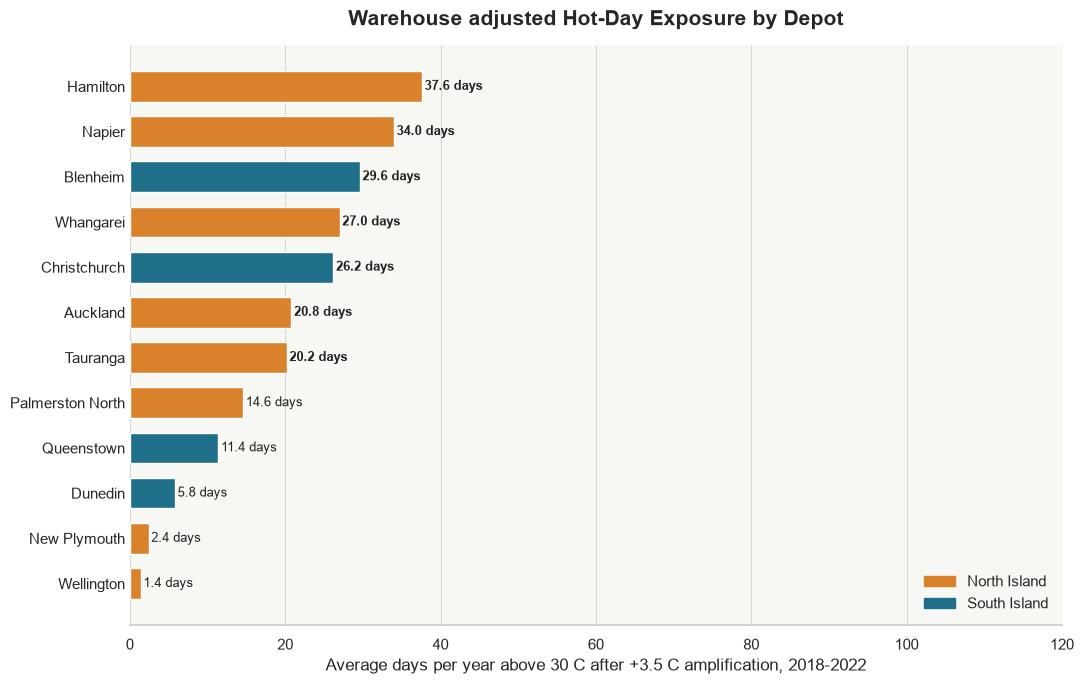

In [7]:
warehouse_hot_days_by_depot = depot_recent_daily.copy()
warehouse_hot_days_by_depot["estimated_warehouse_temp_c"] = (
    warehouse_hot_days_by_depot["temperature"] + WAREHOUSE_AMPLIFICATION["moderate"]
)

annual_warehouse_hot_days_by_depot = (
    warehouse_hot_days_by_depot.groupby(["site", "island", "year"], as_index=False)
    .agg(warehouse_days_above_30c=("estimated_warehouse_temp_c", lambda s: s.gt(30).sum()))
)

warehouse_hot_day_summary = (
    annual_warehouse_hot_days_by_depot.groupby(["site", "island"], as_index=False)
    .agg(warehouse_avg_days_above_30c=("warehouse_days_above_30c", "mean"))
    .sort_values("warehouse_avg_days_above_30c", ascending=False)
)

bar_colors = warehouse_hot_day_summary["island"].map(palette)
positions = np.arange(len(warehouse_hot_day_summary))

fig, ax = plt.subplots(figsize=(11, 7), facecolor="white")
ax.set_facecolor("#F7F7F4")

ax.barh(
    positions,
    warehouse_hot_day_summary["warehouse_avg_days_above_30c"],
    color=bar_colors,
    height=0.68,
)

for y, (_, row) in enumerate(warehouse_hot_day_summary.iterrows()):
    ax.text(
        row["warehouse_avg_days_above_30c"] + 0.35,
        y,
        f"{row['warehouse_avg_days_above_30c']:.1f} days",
        va="center",
        fontsize=9,
        color="#222222",
        fontweight="bold" if row["warehouse_avg_days_above_30c"] >= 15 else "normal",
    )

ax.set_yticks(positions)
ax.set_yticklabels(warehouse_hot_day_summary["site"])
ax.invert_yaxis()
ax.set_title("Warehouse adjusted Hot-Day Exposure by Depot", fontsize=15, pad=14, weight="bold")
ax.set_xlabel("Average days per year above 30 C after +3.5 C amplification, 2018-2022")
ax.set_ylabel("")
ax.grid(axis="x", color="#D7D7D2", linewidth=0.8)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, 120)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#D9822B", label="North Island"),
    plt.Rectangle((0, 0), 1, 1, color="#1F6F8B", label="South Island"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=False)

plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "03_warehouse_adjusted_hot_day_exposure_by_depot.png", dpi=200, bbox_inches="tight")
plt.show()


# 03: How does humidity affect worker heat stress?

Sweat cools through evaporation. High relative humidity slows evaporation, so the same air temperature can feel hotter in humid locations.

Apparent heat calculations use the NOAA Heat Index methodology.

**Key message:** A 30 C warehouse with 80% humidity in Auckland is not equivalent to a 30 C warehouse with 70% humidity in Queenstown.


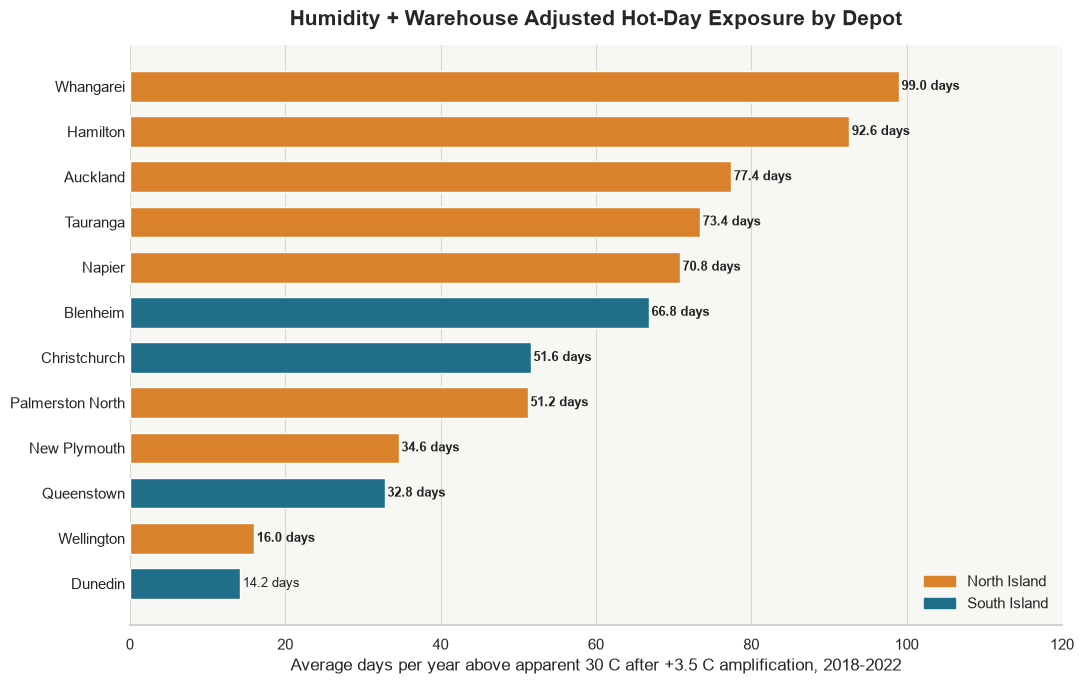

In [8]:
def heat_index_c(temp_c, rh):
    """NOAA heat index approximation. Returns temp for cooler conditions where the formula is not applicable."""
    temp_f = temp_c * 9 / 5 + 32
    hi_f = (
        -42.379
        + 2.04901523 * temp_f
        + 10.14333127 * rh
        - 0.22475541 * temp_f * rh
        - 0.00683783 * temp_f ** 2
        - 0.05481717 * rh ** 2
        + 0.00122874 * temp_f ** 2 * rh
        + 0.00085282 * temp_f * rh ** 2
        - 0.00000199 * temp_f ** 2 * rh ** 2
    )
    hi_c = (hi_f - 32) * 5 / 9
    return np.where((temp_c >= 26.7) & (rh >= 40), hi_c, temp_c)

humidity_adjusted_warehouse_days = warehouse_hot_days_by_depot.merge(
    site_humidity[["site", "summer_rh"]], on="site", how="left"
)
humidity_adjusted_warehouse_days["estimated_warehouse_apparent_temp_c"] = heat_index_c(
    humidity_adjusted_warehouse_days["estimated_warehouse_temp_c"],
    humidity_adjusted_warehouse_days["summer_rh"],
)

annual_humidity_adjusted_hot_days = (
    humidity_adjusted_warehouse_days.groupby(["site", "island", "year"], as_index=False)
    .agg(humidity_adjusted_days_above_30c=("estimated_warehouse_apparent_temp_c", lambda s: s.gt(30).sum()))
)

humidity_adjusted_hot_day_summary = (
    annual_humidity_adjusted_hot_days.groupby(["site", "island"], as_index=False)
    .agg(humidity_adjusted_avg_days_above_30c=("humidity_adjusted_days_above_30c", "mean"))
    .sort_values("humidity_adjusted_avg_days_above_30c", ascending=False)
)

bar_colors = humidity_adjusted_hot_day_summary["island"].map(palette)
positions = np.arange(len(humidity_adjusted_hot_day_summary))

fig, ax = plt.subplots(figsize=(11, 7), facecolor="white")
ax.set_facecolor("#F7F7F4")

ax.barh(
    positions,
    humidity_adjusted_hot_day_summary["humidity_adjusted_avg_days_above_30c"],
    color=bar_colors,
    height=0.68,
)

for y, (_, row) in enumerate(humidity_adjusted_hot_day_summary.iterrows()):
    ax.text(
        row["humidity_adjusted_avg_days_above_30c"] + 0.35,
        y,
        f"{row['humidity_adjusted_avg_days_above_30c']:.1f} days",
        va="center",
        fontsize=9,
        color="#222222",
        fontweight="bold" if row["humidity_adjusted_avg_days_above_30c"] >= 15 else "normal",
    )

ax.set_yticks(positions)
ax.set_yticklabels(humidity_adjusted_hot_day_summary["site"])
ax.invert_yaxis()
ax.set_title("Humidity + Warehouse Adjusted Hot-Day Exposure by Depot", fontsize=15, pad=14, weight="bold")
ax.set_xlabel("Average days per year above apparent 30 C after +3.5 C amplification, 2018-2022")
ax.set_ylabel("")
ax.grid(axis="x", color="#D7D7D2", linewidth=0.8)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, 120)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#D9822B", label="North Island"),
    plt.Rectangle((0, 0), 1, 1, color="#1F6F8B", label="South Island"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=False)

plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "04_humidity_warehouse_adjusted_hot_day_exposure_by_depot.png", dpi=200, bbox_inches="tight")
plt.show()


# 04: What is the estimated productivity impact of heat stress?

This section translates apparent indoor heat into an indicative productivity impact.

Productivity impacts are estimated using the heat-productivity relationship described in the Literature section. Note that the underlying study was conducted in a different context and may not transfer perfectly to New Zealand warehouses.

**Key message:** Heat is not only a comfort issue, but can directly affect labour productivity.

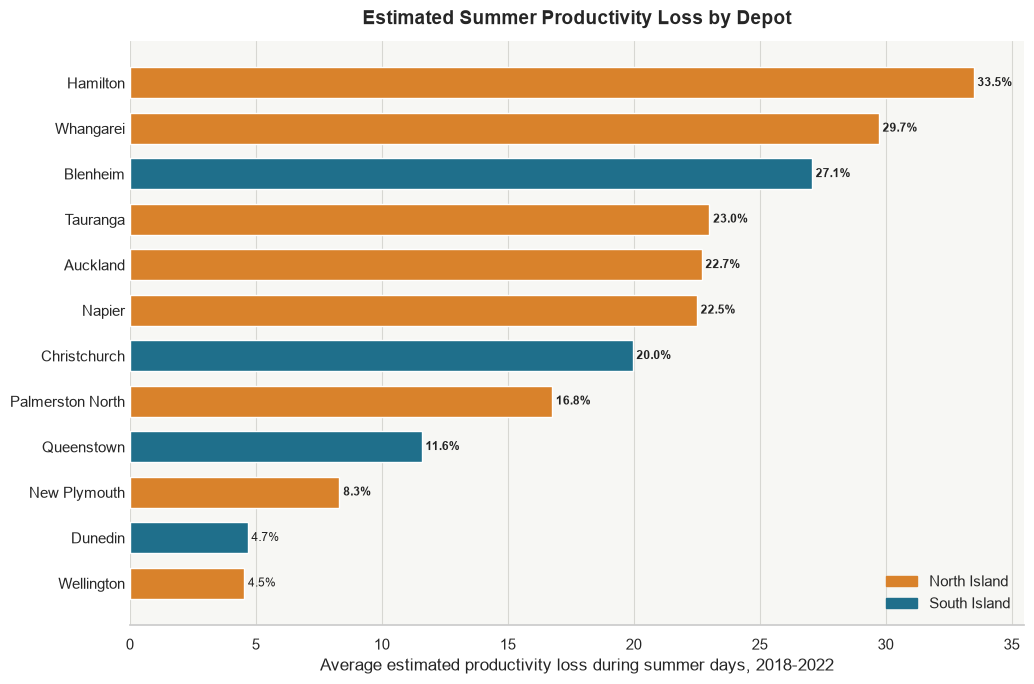

,site,island,estimated_productivity_loss_pct,days_above_productivity_threshold
4,Hamilton,North Island,33.491051,68.6
11,Whangarei,North Island,29.726502,73.2
1,Blenheim,South Island,27.071798,50.2
9,Tauranga,North Island,23.002015,68.4
0,Auckland,North Island,22.695090,65.2
5,Napier,North Island,22.505127,59.2
2,Christchurch,South Island,19.954783,35.6
7,Palmerston North,North Island,16.760433,42.8
8,Queenstown,South Island,11.586422,36.0
6,New Plymouth,North Island,8.319535,34.0


In [9]:
warehouse_risk_daily = warehouse_daily.merge(site_humidity[["site", "summer_rh"]], on="site", how="left")
warehouse_risk_daily["moderate_indoor_temp_c"] = warehouse_risk_daily["warehouse_moderate_temp_c"]
warehouse_risk_daily["moderate_apparent_temp_c"] = heat_index_c(
    warehouse_risk_daily["moderate_indoor_temp_c"], warehouse_risk_daily["summer_rh"]
)
warehouse_risk_daily["excess_heat_c"] = (
    warehouse_risk_daily["moderate_apparent_temp_c"] - PRODUCTIVITY_THRESHOLD_C
).clip(lower=0)
warehouse_risk_daily["productivity_loss_pct"] = (
    warehouse_risk_daily["excess_heat_c"] * PRODUCTIVITY_LOSS_PER_C
) * 100
productivity_summary = (
    warehouse_risk_daily[
        warehouse_risk_daily["month"].isin(SUMMER_MONTHS) & warehouse_risk_daily["year"].between(2018, 2022)
    ]
    .groupby(["site", "island"], as_index=False)
    .agg(
        estimated_productivity_loss_pct=("productivity_loss_pct", "mean"),
        days_above_productivity_threshold=("excess_heat_c", lambda x: (x > 0).sum() / 5),
    )
    .sort_values("estimated_productivity_loss_pct", ascending=False)
)

productivity_plot_data = productivity_summary.sort_values("estimated_productivity_loss_pct", ascending=True)
bar_colors = productivity_plot_data["island"].map(palette)
positions = np.arange(len(productivity_plot_data))

fig, ax = plt.subplots(figsize=(10.5, 7), facecolor="white")
ax.set_facecolor("#F7F7F4")
ax.barh(
    positions,
    productivity_plot_data["estimated_productivity_loss_pct"],
    color=bar_colors,
    height=0.68,
)

for y, (_, row) in enumerate(productivity_plot_data.iterrows()):
    ax.text(
        row["estimated_productivity_loss_pct"] + 0.15,
        y,
        f"{row['estimated_productivity_loss_pct']:.1f}%",
        va="center",
        fontsize=8.5,
        color="#222222",
        fontweight="bold" if row["estimated_productivity_loss_pct"] >= 5 else "normal",
    )

ax.set_yticks(positions)
ax.set_yticklabels(productivity_plot_data["site"])
ax.set_title("Estimated Summer Productivity Loss by Depot", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Average estimated productivity loss during summer days, 2018-2022")
ax.set_ylabel("")
ax.grid(axis="x", color="#D7D7D2", linewidth=0.8)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, max(10, productivity_plot_data["estimated_productivity_loss_pct"].max() + 2.0))

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#D9822B", label="North Island"),
    plt.Rectangle((0, 0), 1, 1, color="#1F6F8B", label="South Island"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=False)

plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "05_estimated_summer_productivity_loss_by_depot.png", dpi=200, bbox_inches="tight")
plt.show()

productivity_summary


# 05: Which Warehouses Are Most Exposed?

The risk score combines four components:

- Warming trend: long-term annual mean trend in C per decade.
- Hot day frequency: recent annual days above 30 C outdoor maximum.
- Humidity burden: summer relative humidity.
- Indoor heat burden: recent summer days above apparent indoor threshold under moderate amplification.

The score is relative across current depot locations, scaled from 0 to 100.


In [10]:
def minmax(series):
    series = pd.to_numeric(series, errors="coerce")
    if series.max() == series.min():
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / (series.max() - series.min())

indoor_threshold_days = (
    warehouse_risk_daily[
        warehouse_risk_daily["month"].isin(SUMMER_MONTHS) & warehouse_risk_daily["year"].between(2018, 2022)
    ]
    .assign(above_threshold=lambda d: d["excess_heat_c"].gt(0))
    .groupby("site", as_index=False)["above_threshold"]
    .sum()
    .rename(columns={"above_threshold": "recent_summer_indoor_threshold_days"})
)
indoor_threshold_days["recent_summer_indoor_threshold_days"] /= 5

recent_hot_days = depot_recent_summary[["site", "avg_hot_days_above_30c"]].rename(
    columns={"avg_hot_days_above_30c": "recent_annual_hot_days_above_30c"}
)

risk_inputs = (
    trend_summary.merge(recent_hot_days, on="site", how="left")
    .merge(site_humidity[["site", "summer_rh"]], on="site", how="left")
    .merge(indoor_threshold_days, on="site", how="left")
)

risk_inputs["trend_component"] = minmax(risk_inputs["warming_trend_c_per_decade"])
risk_inputs["hot_day_component"] = minmax(risk_inputs["recent_annual_hot_days_above_30c"])
risk_inputs["humidity_component"] = minmax(risk_inputs["summer_rh"])
risk_inputs["indoor_heat_component"] = minmax(risk_inputs["recent_summer_indoor_threshold_days"])

risk_inputs["risk_score"] = 100 * (
    0.20 * risk_inputs["trend_component"]
    + 0.30 * risk_inputs["hot_day_component"]
    + 0.20 * risk_inputs["humidity_component"]
    + 0.30 * risk_inputs["indoor_heat_component"]
)

quantiles = risk_inputs["risk_score"].quantile([0.25, 0.50, 0.75]).to_dict()

def risk_level(score):
    if score >= quantiles[0.75]:
        return "Very High"
    if score >= quantiles[0.50]:
        return "High"
    if score >= quantiles[0.25]:
        return "Medium"
    return "Lower"

risk_ranking = risk_inputs.copy()
risk_ranking["risk_level"] = risk_ranking["risk_score"].map(risk_level)
risk_ranking = risk_ranking.sort_values("risk_score", ascending=False)

risk_ranking[[
    "site", "island", "risk_score", "risk_level", "warming_trend_c_per_decade",
    "recent_annual_hot_days_above_30c", "summer_rh", "recent_summer_indoor_threshold_days"
]]


,site,island,risk_score,risk_level,warming_trend_c_per_decade,recent_annual_hot_days_above_30c,summer_rh,recent_summer_indoor_threshold_days
7,Blenheim,South Island,66.668020,Very High,0.153324,8.8,74.500000,50.2
4,Hamilton,North Island,64.792973,Very High,0.188353,2.6,79.866667,68.6
3,Napier,North Island,59.436422,Very High,0.194524,7.4,67.966667,59.2
1,Auckland,North Island,55.221748,High,0.247012,0.0,77.833333,65.2
5,Tauranga,North Island,53.968023,High,0.183484,2.0,74.200000,68.4
8,Christchurch,South Island,53.552047,High,0.150411,6.8,75.200000,35.6
10,Whangarei,North Island,52.868921,Medium,0.082742,0.4,80.166667,73.2
2,Palmerston North,North Island,45.218349,Medium,0.211925,1.2,77.300000,42.8
0,Queenstown,South Island,41.707397,Medium,0.327402,1.4,71.433333,36.0
6,New Plymouth,North Island,40.145041,Lower,0.168523,0.0,81.533333,34.0


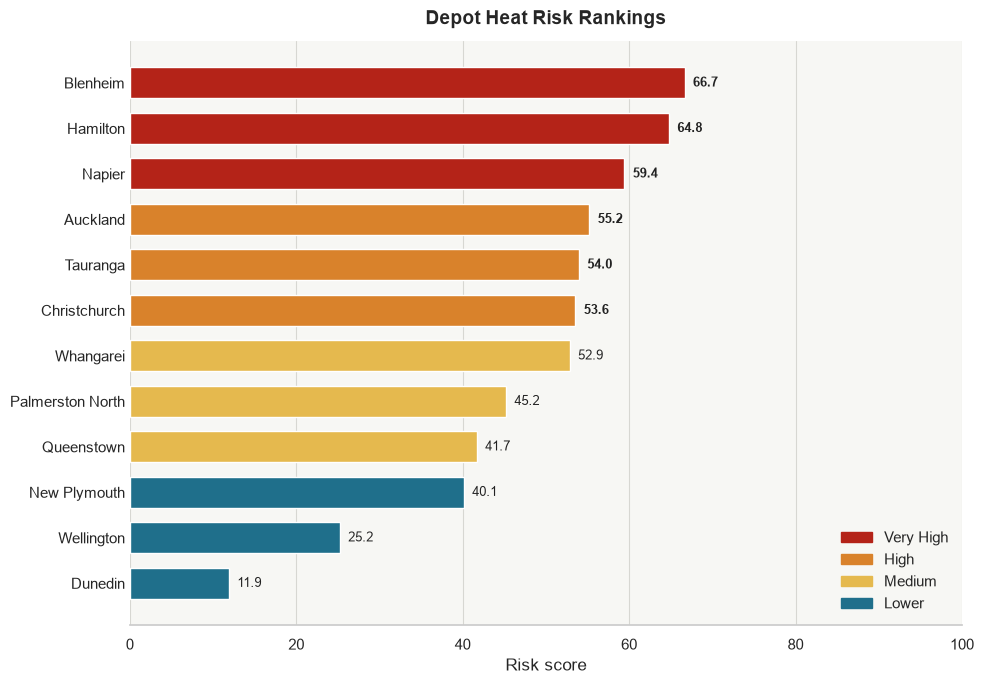

In [11]:
risk_plot_data = risk_ranking.sort_values("risk_score", ascending=True)
risk_palette = {
    "Very High": "#B42318",
    "High": "#D9822B",
    "Medium": "#E5B94E",
    "Lower": "#1F6F8B",
}
bar_colors = risk_plot_data["risk_level"].map(risk_palette)
positions = np.arange(len(risk_plot_data))

fig, ax = plt.subplots(figsize=(10, 7), facecolor="white")
ax.set_facecolor("#F7F7F4")
ax.barh(positions, risk_plot_data["risk_score"], color=bar_colors, height=0.68)

for y, (_, row) in enumerate(risk_plot_data.iterrows()):
    ax.text(
        row["risk_score"] + 1.0,
        y,
        f"{row['risk_score']:.1f}",
        va="center",
        fontsize=9,
        color="#222222",
        fontweight="bold" if row["risk_level"] in {"High", "Very High"} else "normal",
    )

ax.set_yticks(positions)
ax.set_yticklabels(risk_plot_data["site"])
ax.set_title("Depot Heat Risk Rankings", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Risk score")
ax.set_ylabel("")
ax.grid(axis="x", color="#D7D7D2", linewidth=0.8)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, max(100, risk_plot_data["risk_score"].max() + 8))

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=level)
    for level, color in risk_palette.items()
]
ax.legend(handles=legend_handles, loc="lower right", frameon=False)

plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "06_heat_risk_rankings.png", dpi=200, bbox_inches="tight")
plt.show()

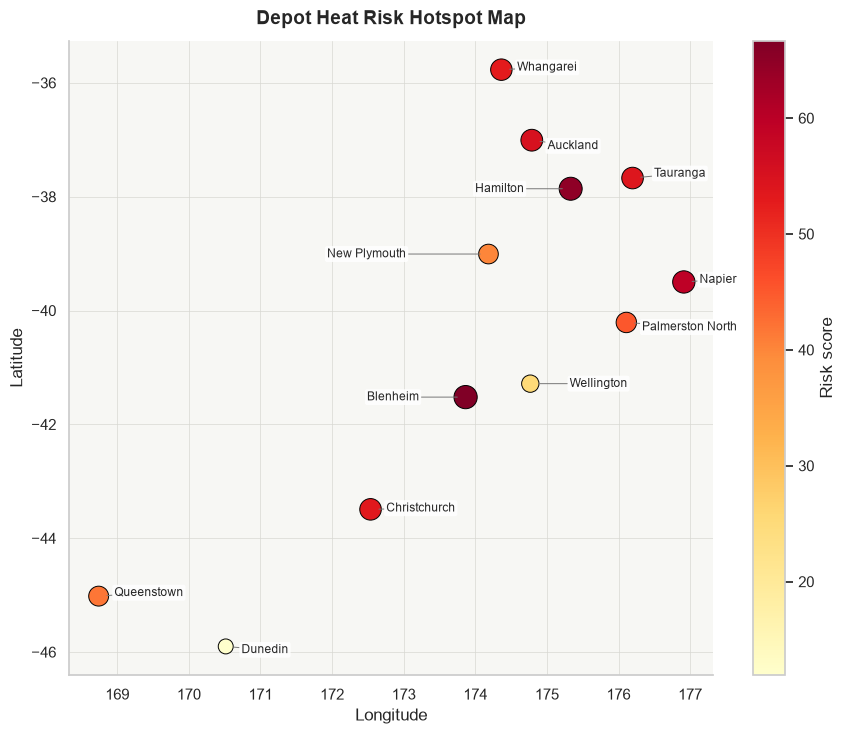

In [12]:
fig, ax = plt.subplots(figsize=(9, 7.5), facecolor="white")
ax.set_facecolor("#F7F7F4")
map_data = risk_ranking.merge(temp[["site", "lat", "lon"]].drop_duplicates("site"), on="site", how="left")
scatter = ax.scatter(
    map_data["lon"], map_data["lat"],
    s=80 + map_data["risk_score"] * 3,
    c=map_data["risk_score"],
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.7,
    zorder=3,
)

label_offsets = {
    "Auckland": (0.22, -0.10),
    "Hamilton": (-0.65, 0.00),
    "Tauranga": (0.30, 0.08),
    "Whangarei": (0.22, 0.04),
    "New Plymouth": (-1.15, 0.00),
    "Napier": (0.22, 0.04),
    "Palmerston North": (0.22, -0.08),
    "Wellington": (0.55, 0.00),
    "Blenheim": (-0.65, 0.00),
    "Christchurch": (0.22, 0.02),
    "Queenstown": (0.22, 0.06),
    "Dunedin": (0.22, -0.06),
}
for _, row in map_data.iterrows():
    dx, dy = label_offsets.get(row["site"], (0.22, 0.04))
    ha = "right" if dx < 0 else "left"
    ax.annotate(
        row["site"],
        xy=(row["lon"], row["lat"]),
        xytext=(row["lon"] + dx, row["lat"] + dy),
        fontsize=8.5,
        ha=ha,
        va="center",
        bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "none", "alpha": 0.86},
        arrowprops={"arrowstyle": "-", "color": "#777777", "lw": 0.7, "shrinkA": 0, "shrinkB": 6},
        zorder=4,
    )
ax.set_title("Depot Heat Risk Hotspot Map", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(color="#D7D7D2", linewidth=0.7, alpha=0.7)
ax.spines[["top", "right"]].set_visible(False)
plt.colorbar(scatter, ax=ax, label="Risk score")
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "07_warehouse_heat_map.png", dpi=200, bbox_inches="tight")
plt.show()


# 06: What Can Be Done?

This section models the cheapest intervention: fan-assisted cooling. The scenario assumes air movement of 3 m/s, producing an estimated perceived cooling effect of 7°C.

The table below gives context for other possible cooling options.

| Intervention | Indicative cost | Expected impact |
|---|---:|---:|
| Fans | Low | High |
| HVLS fans | Medium | High |
| Ventilation improvements | Medium | Medium |
| Insulation / roof treatment | High | Medium |
| Full air conditioning | Very High | Highest |

**Key message:** A fan blowing at 3 m/s may materially reduce perceived heat exposure, while broader cooling options require separate cost-benefit analysis.

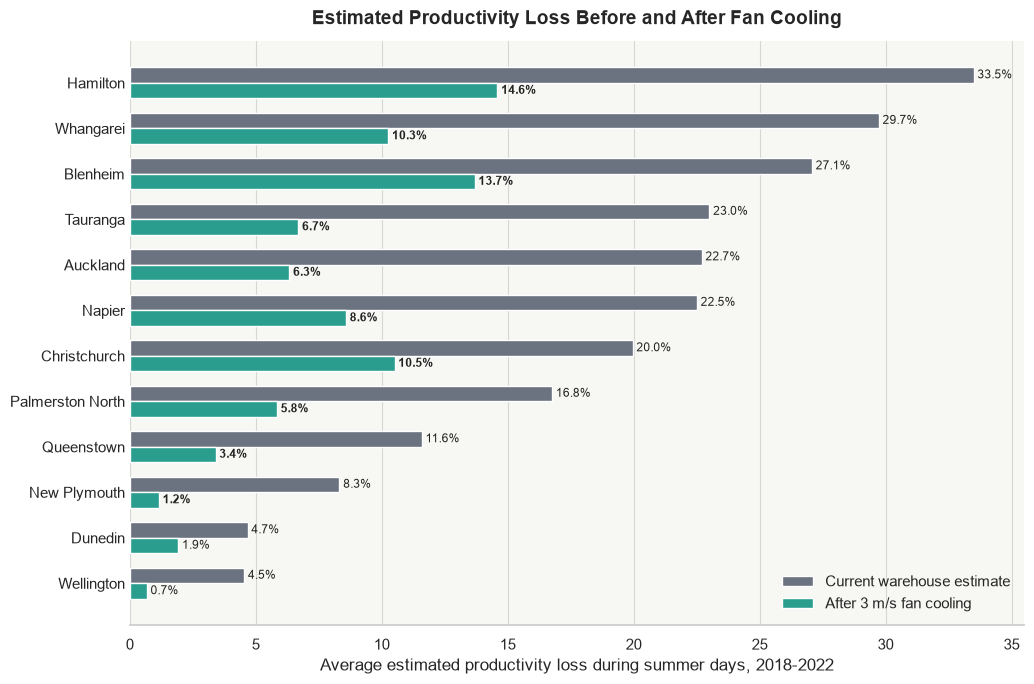

,site,island,estimated_productivity_loss_pct,fan_cooled_productivity_loss_pct,productivity_loss_reduction_pct
11,Wellington,North Island,4.538858,0.670976,3.867882
10,Dunedin,South Island,4.672850,1.920917,2.751933
9,New Plymouth,North Island,8.319535,1.154334,7.165201
8,Queenstown,South Island,11.586422,3.400382,8.186039
7,Palmerston North,North Island,16.760433,5.835331,10.925102
6,Christchurch,South Island,19.954783,10.506500,9.448283
5,Napier,North Island,22.505127,8.578129,13.926998
4,Auckland,North Island,22.695090,6.327439,16.367651
3,Tauranga,North Island,23.002015,6.683785,16.318230
2,Blenheim,South Island,27.071798,13.687609,13.384190


In [13]:
FAN_COOLING_EFFECT_C = 7.0

fan_cooled_warehouse_days = humidity_adjusted_warehouse_days.copy()
fan_cooled_warehouse_days["fan_cooled_apparent_temp_c"] = (
    fan_cooled_warehouse_days["estimated_warehouse_apparent_temp_c"] - FAN_COOLING_EFFECT_C
)
fan_cooled_warehouse_days["fan_cooled_excess_heat_c"] = (
    fan_cooled_warehouse_days["fan_cooled_apparent_temp_c"] - PRODUCTIVITY_THRESHOLD_C
).clip(lower=0)
fan_cooled_warehouse_days["fan_cooled_productivity_loss_pct"] = (
    fan_cooled_warehouse_days["fan_cooled_excess_heat_c"] * PRODUCTIVITY_LOSS_PER_C
) * 100

fan_cooled_productivity_summary = (
    fan_cooled_warehouse_days[
        fan_cooled_warehouse_days["month"].isin(SUMMER_MONTHS) & fan_cooled_warehouse_days["year"].between(2018, 2022)
    ]
    .groupby(["site", "island"], as_index=False)
    .agg(fan_cooled_productivity_loss_pct=("fan_cooled_productivity_loss_pct", "mean"))
)

fan_cooling_comparison = (
    productivity_summary[["site", "island", "estimated_productivity_loss_pct"]]
    .merge(fan_cooled_productivity_summary, on=["site", "island"], how="left")
    .assign(
        productivity_loss_reduction_pct=lambda d: d["estimated_productivity_loss_pct"] - d["fan_cooled_productivity_loss_pct"]
    )
    .sort_values("estimated_productivity_loss_pct", ascending=True)
)

positions = np.arange(len(fan_cooling_comparison))
bar_height = 0.34

fig, ax = plt.subplots(figsize=(10.5, 7), facecolor="white")
ax.set_facecolor("#F7F7F4")

ax.barh(
    positions + bar_height / 2,
    fan_cooling_comparison["estimated_productivity_loss_pct"],
    color="#6B7280",
    height=bar_height,
    label="Current warehouse estimate",
)
ax.barh(
    positions - bar_height / 2,
    fan_cooling_comparison["fan_cooled_productivity_loss_pct"],
    color="#2A9D8F",
    height=bar_height,
    label="After 3 m/s fan cooling",
)

for y, (_, row) in enumerate(fan_cooling_comparison.iterrows()):
    ax.text(
        row["estimated_productivity_loss_pct"] + 0.15,
        y + bar_height / 2,
        f"{row['estimated_productivity_loss_pct']:.1f}%",
        va="center",
        fontsize=8.5,
        color="#222222",
    )
    ax.text(
        row["fan_cooled_productivity_loss_pct"] + 0.15,
        y - bar_height / 2,
        f"{row['fan_cooled_productivity_loss_pct']:.1f}%",
        va="center",
        fontsize=8.5,
        color="#222222",
        fontweight="bold" if row["productivity_loss_reduction_pct"] >= 5 else "normal",
    )

ax.set_yticks(positions)
ax.set_yticklabels(fan_cooling_comparison["site"])
ax.set_title("Estimated Productivity Loss Before and After Fan Cooling", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Average estimated productivity loss during summer days, 2018-2022")
ax.set_ylabel("")
ax.grid(axis="x", color="#D7D7D2", linewidth=0.8)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, max(10, fan_cooling_comparison["estimated_productivity_loss_pct"].max() + 2.0))
ax.legend(loc="lower right", frameon=False)

plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "08_fan_cooling_productivity_loss_comparison_by_depot.png", dpi=200, bbox_inches="tight")
plt.show()

fan_cooling_comparison